# Decision Trees Classifier
Here the features can be numerical or categorical

### Import Libraries

In [1]:
from sklearn.tree            import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder
from sklearn.metrics         import accuracy_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
# plt.style.use("dark_background")

import pandas as pd
import numpy as np
from sklearn import tree
%matplotlib inline

# 1. Problem Formulation
You have a training data given to you of Iris flower.
Design a ML model that would predict the label (setosa, virginica, versicolor) of a data (sepal_length, sepal_width, petal_length, petal_width) taken from iris flower

# 2. Data collection

In [2]:
df = pd.read_csv("data_iris.csv")
print(df.head(5))

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


# 3. Data labelling
The data is already labeled

# 4. EDA
You can perform EDA here

# 5. Label encoding and data split ( Train + Test )

In [3]:
# Separate features(X) and labels(y):
X = df[["sepal_length", "sepal_width", "petal_length", "petal_width"]]
y = df["species"]

print("X:\n", X)
print("y:\n", y)

X:
      sepal_length  sepal_width  petal_length  petal_width
0             5.1          3.5           1.4          0.2
1             4.9          3.0           1.4          0.2
2             4.7          3.2           1.3          0.2
3             4.6          3.1           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[150 rows x 4 columns]
y:
 0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: object


In [6]:
# Encode labels BEFORE splitting
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Encoded labels:", y_encoded[:10]) # print 1st 10 values
print("Classes:", encoder.classes_)
print("Labels :", encoder.transform(encoder.classes_))

Encoded labels: [0 0 0 0 0 0 0 0 0 0]
Classes: ['setosa' 'versicolor' 'virginica']
Labels : [0 1 2]


In [7]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3,
                                                    random_state=42, shuffle=True)

# test_size=0.3 means 30% of the data is used for testing
# random_state ensures reproducibility of the split

print("Shape of training dataset:", X_train.shape) # 105 rows and 4 columns
print("Shape of testing dataset:", X_test.shape) # 105 rows and 4 columns

Shape of training dataset: (105, 4)
Shape of testing dataset: (45, 4)


In [8]:
# Now lets make sure that you have balanced target variable in training data

values, counts = np.unique(y_train, return_counts=True)
value_counts = dict(zip(values, counts))
print(value_counts)

{0: 31, 1: 37, 2: 37}


# 6. Data Preprocessing and Feature Engineering


# 7. Modeling + Training
I am picking Decision Tree model

In [9]:
# max_depth: The length of the longest path from a root node to a leaf node will not exceed this value.
# This is the most commonly tuned hyperparameter for tree-based method. Here I will uses default value
model = DecisionTreeClassifier(max_depth=2, # Try to change this to 3 and 4 and accuracy would go , but may be overfiting. 
                             random_state=0)

In [10]:
# train the model
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=0)

In [11]:
# Lets print all hyperparam
print(model.get_params())

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 2, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 0, 'splitter': 'best'}


# 8. Model Performance + Evaluation

In [10]:
# I picked following 3 points from data and checked their prediction:
sample = [
    [5.1, 3.5, 1.4, 0.2], # actual--> setosa
    [7, 3.2, 4.7, 1.4],   # actual--> versicolor
    [6.3, 3.3, 6, 2.5],   # actual--> virginica
]
          
sample_df = pd.DataFrame(sample, columns=X.columns)

prediction = model.predict(sample_df)
decoded    = [encoder.classes_[p] for p in prediction]

print("Prediction:", prediction)
print("Predicted classes:", decoded)

Prediction: [0 1 2]
Predicted classes: ['setosa', 'versicolor', 'virginica']


In [11]:
# Make predictions on the test set
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual(encoded)": y_test,
    "Predicted(encoded)": y_pred,
    "Actual(label)": encoder.classes_[y_test],
    "Predicted(label)": encoder.classes_[y_pred], 
    "Match": (y_test == y_pred).astype(int)   # 1 = correct, 0 = incorrect
})

print(results)

    Actual(encoded)  Predicted(encoded) Actual(label) Predicted(label)  Match
0                 1                   1    versicolor       versicolor      1
1                 0                   0        setosa           setosa      1
2                 2                   2     virginica        virginica      1
3                 1                   1    versicolor       versicolor      1
4                 1                   2    versicolor        virginica      0
5                 0                   0        setosa           setosa      1
6                 1                   1    versicolor       versicolor      1
7                 2                   2     virginica        virginica      1
8                 1                   1    versicolor       versicolor      1
9                 1                   1    versicolor       versicolor      1
10                2                   2     virginica        virginica      1
11                0                   0        setosa           

Accuracy is defined as(fraction of correct predictions)

- correct predictions / total number of data points

In [12]:
# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.9778


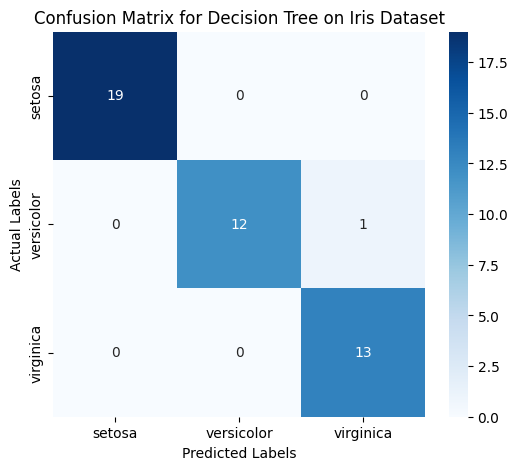

In [14]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm,
            annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("Confusion Matrix for Decision Tree on Iris Dataset")
plt.show()

## Visualize Decision Trees using Matplotlib

Decision Trees can now be plotted with matplotlib using scikit-learn's `tree.plot_tree` . 

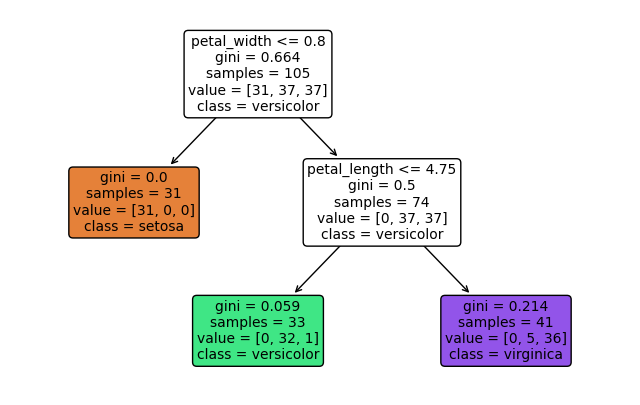

In [20]:
plt.figure(figsize=(8, 5))
tree.plot_tree(
    model,
    filled=True,
    rounded=True,
    feature_names=X.columns,
    class_names=encoder.classes_,
    fontsize=10
)

plt.show()
# fig.savefig('plottreefncn.png') # optional if u want to save 

### Hyperparameter Tuning
The default tree is quite complex, and we need to simplify it by tuning the hyperparameters.

First, let's understand the parameters in a decision tree. You can read this in the documentation using help(DecisionTreeClassifier).

- criterion (Gini/IG or entropy): It defines the function to measure the quality of a split. Sklearn supports “gini” criteria for Gini Index & “entropy” for Information Gain. By default, it takes the value “gini”.
- splitter: It defines the strategy to choose the split at each node. Supports “best” value to choose the best split & “random” to choose the best random split. By default, it takes “best” value.
- max_features: It defines the no. of features to consider when looking for the best split. We can input integer, float, string & None value.
- max_depth: The max_depth parameter denotes maximum depth of the tree. It can take any integer value or None. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples. By default, it takes “None” value.
- min_samples_split: This tells above the minimum no. of samples reqd. to split an internal node. If an integer value is taken then consider min_samples_split as the minimum no. If float, then it shows percentage. By default, it takes “2” value.
- min_samples_leaf: The minimum number of samples required to be at a leaf node. If an integer value is taken then consider - -min_samples_leaf as the minimum no. If float, then it shows percentage. By default, it takes “1” value.
- max_leaf_nodes: It defines the maximum number of possible leaf nodes. If None then it takes an unlimited number of leaf nodes. By default, it takes “None” value.
- min_impurity_split: It defines the threshold for early stopping tree growth. A node will split if its impurity is above the threshold otherwise it is a leaf.

## Grid Search to Find Optimal Hyperparameters
#### We can now use GridSearchCV to find multiple optimal hyperparameters together. Note that this time, we'll also specify the criterion (gini/entropy or IG).

In [21]:
# GridSearchCV to find optimal min_samples_split
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV

# Create the parameter grid 
param_grid = {
    'max_depth': range(1, 8, 1),
    'min_samples_leaf': range(1, 10, 2),
    'min_samples_split': range(2, 10, 2),
    'criterion': ["entropy", "gini"]
}

n_folds = 5

# Instantiate the grid search model
iristree = DecisionTreeClassifier()
grid_search = GridSearchCV(estimator = iristree,
                           param_grid = param_grid, 
                           cv = n_folds,
                           verbose = 1)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 280 candidates, totalling 1400 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['entropy', 'gini'],
                         'max_depth': range(1, 8),
                         'min_samples_leaf': range(1, 10, 2),
                         'min_samples_split': range(2, 10, 2)},
             verbose=1)

In [22]:
# cv results
cv_results = pd.DataFrame(grid_search.cv_results_)
print(cv_results)

     mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0         0.002006      0.000022         0.001798        0.000415   
1         0.002392      0.000483         0.002201        0.000399   
2         0.003396      0.002336         0.002003        0.000006   
3         0.005011      0.002617         0.002786        0.000384   
4         0.002000      0.000002         0.001806        0.000750   
..             ...           ...              ...             ...   
275       0.001801      0.000401         0.001199        0.000400   
276       0.001599      0.000494         0.001402        0.000493   
277       0.001789      0.000401         0.001412        0.000500   
278       0.002002      0.000027         0.001198        0.000402   
279       0.001989      0.000015         0.001410        0.000488   

    param_criterion param_max_depth param_min_samples_leaf  \
0           entropy               1                      1   
1           entropy               1            

In [23]:
# printing the optimal accuracy score and hyperparameters
print("best accuracy", grid_search.best_score_)
print(grid_search.best_estimator_)

best accuracy 0.9428571428571428
DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=5)


### Running the model with best parameters obtained from grid search

In [25]:
# model with optimal hyperparameters
model_best = DecisionTreeClassifier(criterion = "entropy",
                  random_state = 100,
                  max_depth=4, 
                  min_samples_leaf=3,
                  min_samples_split=2
)
model_best.fit(X_train, y_train)

# accuracy score
print(model_best.score(X_test, y_test))

1.0

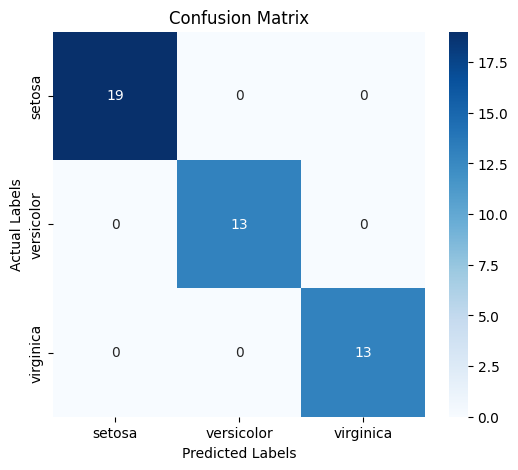

In [29]:
y_pred = model_best.predict(X_test)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm,
            annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("Confusion Matrix")
plt.show()

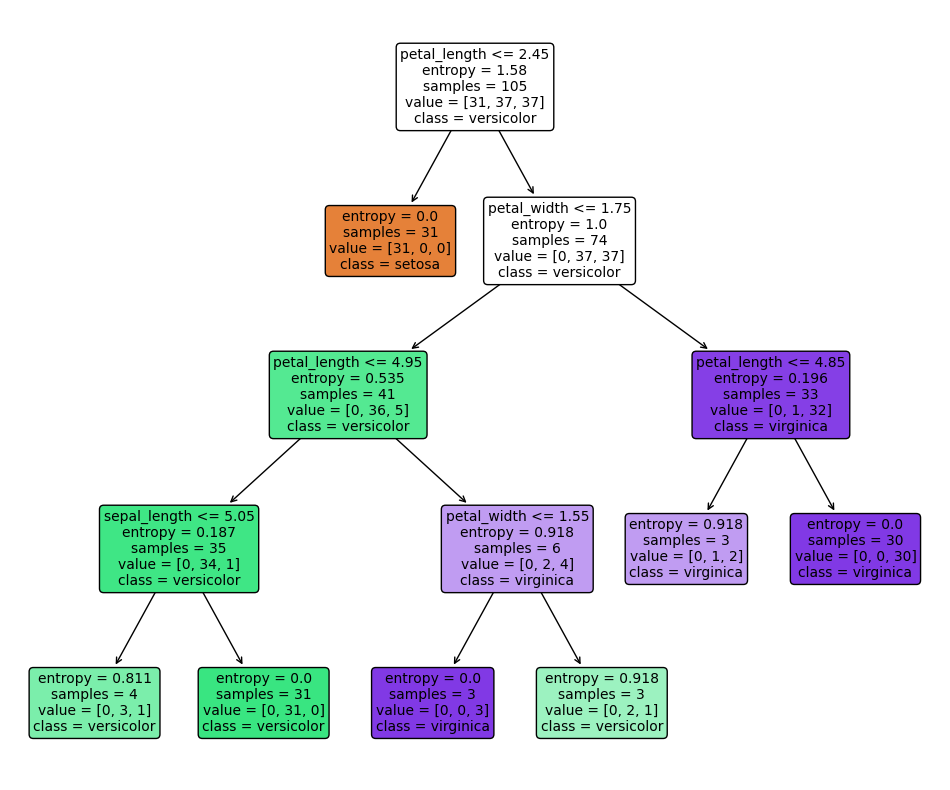

In [28]:
plt.figure(figsize=(12, 10))
tree.plot_tree(
    model_best,
    filled=True,
    rounded=True,
    feature_names=X.columns,
    class_names=encoder.classes_,
    fontsize=10
)

plt.show()
# fig.savefig('plottreefncn.png') # optional if u want to save 

### Better than above. 